# Lab | Text Generation from Shakespeare's Sonnet

This notebook explores the fascinating domain of text generation using a deep learning model trained on Shakespeare's sonnets.

The objective is to create a neural network capable of generating text sequences that mimic the style and language of Shakespeare.

By utilizing a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) layers, this project aims to demonstrate how a model can learn and replicate the complex patterns of early modern English.

The dataset used consists of Shakespeare's sonnets, which are preprocessed and tokenized to serve as input for the model.

Throughout this notebook, you will see the steps taken to prepare the data, build and train the model, and evaluate its performance in generating text.

This lab provides a hands-on approach to understanding the intricacies of natural language processing (NLP) and the potential of machine learning in creative text generation.

In [ ]:
!git clone https://github.com/mahmoodasayeedi/lab-text-generation-shakespeare.git

fatal: destination path 'lab-text-generation-shakespeare' already exists and is not an empty directory.


Let's import necessary libraries

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku
import numpy as np
from tensorflow.keras.regularizers import l2

Let's get the data!

In [ ]:
import requests
url = 'https://raw.githubusercontent.com/martin-gorner/tensorflow-rnn-shakespeare/master/shakespeare/sonnets.txt'
resp = requests.get(url)
with open('sonnets.txt', 'wb') as f:
    f.write(resp.content)

data = open('sonnets.txt').read()

corpus = data.lower().split("\n")

Step 1: Initialise a tokenizer and fit it on the corpus variable using .fit_on_texts

In [ ]:
#  Initialise a tokenizer
Tokenizer = Tokenizer()

# Fit the tokenizer on the corpus
Tokenizer.fit_on_texts(corpus)

Step 2: Calculate the Vocabulary Size

Let's figure out how many unique words are in your corpus. This will be the size of your vocabulary.

Calculate the length of tokenizer.word_index, add 1 to it and store it in a variable called total_words.

In [ ]:
from requests.auth import to_native_string

#Calculate Vocabulary
total_words = len(Tokenizer.word_index) + 1

print("Total words",total_words)

Total words 3375


Create an empty list called input_sequences.

For each sentence in your corpus, convert the text into a sequence of integers using the tokenizer.
Then, generate n-gram sequences from these tokens.

Store the result in the list input_sequences.

In [ ]:
#create a empty list
input_sequence = []

#convert the text into sequence of integers using tokenizer
for line in corpus:
    token_list = Tokenizer.texts_to_sequences([line])[0]

    #generate n-gram sequences from these tokens
    for i in range(1,len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequence.append(n_gram_sequence)


Calculate the length of the longest sequence in input_sequences. Assign the result to a variable called max_sequence_len.

Now pad the sequences using pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre').
Convert it to a numpy array and assign the result back to our variable called input_sequences.

In [ ]:
# calculating maximum sequence
max_sequence_len = max([len(x) for x in input_sequence])

# padding sequences
input_sequences = np.array(pad_sequences(input_sequence, maxlen=max_sequence_len, padding='pre'))


Prepare Predictors and Labels

Split the sequences into two parts:

- Predictors: All elements from input_sequences except the last one.
- Labels: The last element of each sequence in input_sequences.

In [ ]:
# Split the sequence into Predicators & labels
predictors, labels = input_sequences[:,:-1], input_sequences[:,-1]


One-Hot Encode the Labels :

Convert the labels (which are integers) into one-hot encoded vectors.

Ensure the length of these vectors matches the total number of unique words in your vocabulary.

Use ku.to_categorical() on labels with num_classes = total_words

Assign the result back to our variable labels.

In [ ]:
#Convert the labels (which are integers) into one-hot encoded vectors.
labels = ku.to_categorical(labels, num_classes=total_words)



# Initialize the Model

Start by creating a Sequential model.

Add Layers to the Model:

Embedding Layer: The first layer is an embedding layer. It converts word indices into dense vectors of fixed size (100 in this case). Set the input length to the maximum sequence length minus one, which corresponds to the number of previous words the model will consider when predicting the next word.

Bidirectional LSTM Layer: Add a Bidirectional LSTM layer with 150 units. This layer allows the model to learn context from both directions (past and future) in the sequence. return_sequences=True

Dropout Layer: Add a dropout layer with a rate of 0.2 to prevent overfitting by randomly setting 20% of the input units to 0 during training.

LSTM Layer: Add a second LSTM layer with 100 units. This layer processes the sequence and passes its output to the next layer.

Dense Layer (Intermediate): Add a dense layer with half the total number of words as units, using ReLU activation. A regularization term (L2) is added to prevent overfitting.

Dense Layer (Output): The final dense layer has as many units as there are words in the vocabulary, with a softmax activation function to output a probability distribution over all words.

In [ ]:

model = Sequential([
     # 1. Embedding Layer
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_length=max_sequence_len - 1
    ),
   # 2. Bidirectional LSTM Layer
    Bidirectional(LSTM(150, return_sequences=True)),
   # 3. Dropout Layer
    Dropout(0.2),
   # 4. Standard LSTM Layer
    LSTM(100),
   # 5. Intermediate Dense Layer (with ReLU and L2 Regularization)
    Dense(
        units=total_words // 2,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),
    # 6. Output Dense Layer (with Softmax)
    Dense(
        units=total_words,
        activation='softmax'
    )

])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Compile the Model:

Compile the model using categorical crossentropy as the loss function, the Adam optimizer for efficient training, and accuracy as the metric to evaluate during training.

In [ ]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


# Print Model Summary:

Use model.summary() to print a summary of the model, which shows the layers, their output shapes, and the number of parameters.

In [ ]:
# Print summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Now train the model for 50 epochs and assign it to a variable called history.

Training the model with 50 epochs should get you around 40% accuracy.

You can train the model for as many epochs as you like depending on the time and computing constraints you are facing. Ideally train it for a larger amount of epochs than 50.

That way you will get better text generation at the end.

However, dont waste your time.

In [ ]:
# Train the model for 50 epochs
history = model.fit(
    predictors,     # input word sequence matrix (X)
    labels,          # one-hot encoded target word vectors (y)
    epochs=50,      # Iterates over the full dataset 50 times
    verbose=1       # Prints a live progress bar and accuracy tracker for each epoch
)

print("\nTraining completed successfully!")


Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0205 - loss: 6.9119
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0223 - loss: 6.5055
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0248 - loss: 6.3973
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0300 - loss: 6.2843
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0353 - loss: 6.2003
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.0386 - loss: 6.1295
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0404 - loss: 6.0589
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0435 - loss: 5.9974
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0451 - loss: 5.9258
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0516 - loss: 5.8454
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0548 - loss: 5.7574
Epoch 12/50
484/484 ━━━━━━━━━━━━━━━━━━━━

# Use plt from matplotlib to plot the training accuracy over epochs and the loss over epochs

First you will have to get the accuracy and loss data over epochs, you can do this by using methods on your model.

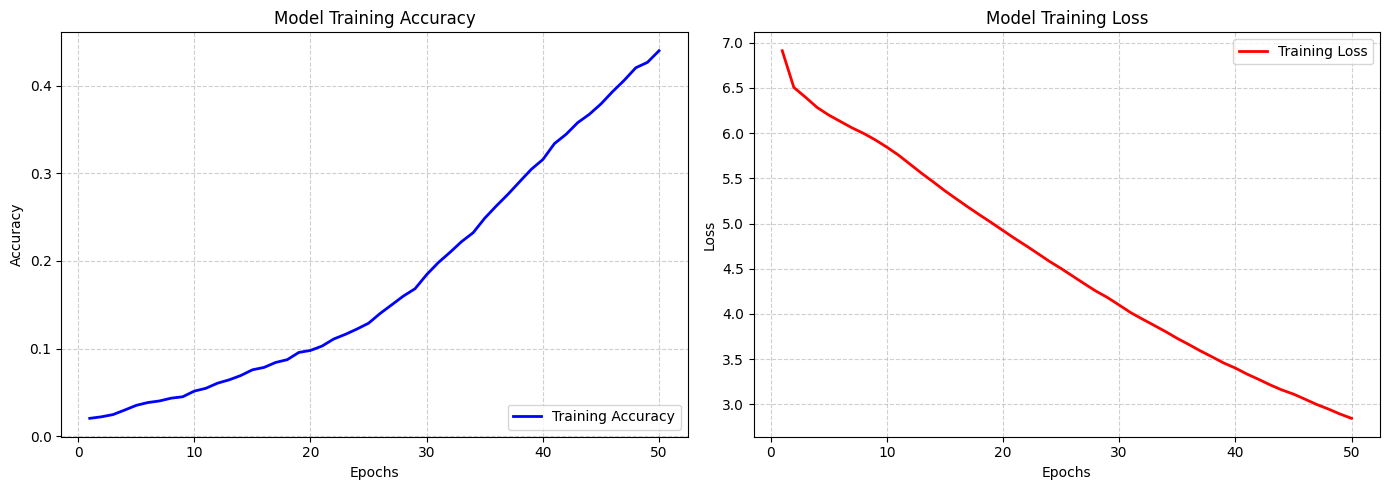

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
loss = history.history['loss']

# Create a range list matching your total number of epochs (1 to 50)
epochs_range = range(1, len(acc) + 1)

# 2. Set up the plotting window figure size
plt.figure(figsize=(14, 5))

# =========================================================================
# PLOT 1: TRAINING ACCURACY OVER EPOCHS
# =========================================================================
plt.subplot(1, 2, 1) # Left window panel
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.title('Model Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# =========================================================================
# PLOT 2: TRAINING LOSS OVER EPOCHS
# =========================================================================
plt.subplot(1, 2, 2) # Right window panel
plt.plot(epochs_range, loss, label='Training Loss', color='red', linewidth=2)
plt.title('Model Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Display the clean layout
plt.tight_layout()
plt.show()


# Generate text with the model based on a seed text

Now you will create two variables :

- seed_text = 'Write the text you want the model to use as a starting point to generate the next words'
- next_words = number_of_words_you_want_the_model_to_generate

Please change number_of_words_you_want_the_model_to_generate by an actual integer.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

seed_text = "help me pick up the pieces of my"
next_words = 15


Now create a loop that runs based on the next_words variable and generates new text based on your seed_text input string. Print the full text with the generated text at the end.

This time you dont get detailed instructions.

Have fun!

In [ ]:
def generate_text(seed_text, next_words):
  for _ in range(next_words):
    # Convert current text sentence into a sequence of numeric token indices
    token_list = Tokenizer.texts_to_sequences([seed_text])[0]

    # Pad the sequence to match the model's exact expected sequence input length
    # Max input length is max_sequence_len - 1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    # Predict the probability distribution array over
    predicted_probs = model.predict(token_list, verbose=0)

    # Grab the index number of the word with the highest probability score (argmax)
    predicted_index = np.argmax(predicted_probs, axis=-1)[0]

    # Look up the actual text string matching that index in the tokenizer's vocabulary dictionary
    output_word = ""
    for word, index in Tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break

    # Append the newly predicted word onto the text sentence so it can be used for the next loop cycle
    seed_text += " " + output_word

  return seed_text


Experiment with at least 3 different seed_text strings and see what happens!

In [ ]:
# Define 3 different experimental seeds
seeds = [
    "i am planning to",
    "yesterday i saw a",
    "the secret to success is"
]

for seed in seeds:
    print(f"Original text : '{seed}' ---")

    # calling function
    result = generate_text(seed, next_words=14)
    print(result)
    print("\n" + "="*40 + "\n")



Original text : 'i am planning to' ---
i am planning to whom my love is wanting behind doth see me well might is thee was


Original text : 'yesterday i saw a' ---
yesterday i saw a world is dressing old gay held light still alone best it boast you to


Original text : 'the secret to success is' ---
the secret to success is persuade a salve is onward of of sight fitted last still memory lie of


